# Tirol Ski Resort Snow-Line Exposure Analysis

Same analytical shape as the NYC hydrant density project: load, explore, spatial join, aggregate, export.

**Data sources (fetched once via `00_fetch_data.py` — run that first if the `data_*` files below aren't present):**
- Official ski area boundaries — Land Tirol "URP Schigebietsgrenzen" (103 legally-defined areas)
- Tirol province outline — OpenStreetMap admin boundary (map background context only)
- Pistes — OpenStreetMap via Overpass
- On-mountain venues (restaurants/bars) — Overture Places, queried via DuckDB on S3
- Elevation — Land Tirol digital terrain model, via WCS (tiris)

**What you'll find in each chapter:**
1. Load boundaries + pistes, rank resorts by size
2. Map all resort boundaries
3. Snow-line exposure — % below 1800m, km below 1800m, and km above 1800m by difficulty
4. On-mountain venue counts
5. Venue density (venues per km²)
6. Visual density map
7. Export to GeoParquet

## 0a. Fetch Data

Runs `00_fetch_data.py`, which pulls all data sources needed for this analysis. Safe to
run every time — it checks for each file locally first and skips anything already downloaded,
so after the first run this completes in under a second.

In [1]:
!python 00_fetch_data.py

Fetching official Tirol ski area boundaries...
  Saved 1.4 MB to urp_schigebietsgrenzen.geojson
Fetching Tirol province boundary...
  Saved Tirol boundary to data_tirol_boundary.gpkg
Fetching all Tirol pistes...
  Saved 10390 piste segments to data_pistes.gpkg
Fetching all Tirol venues (Overture Places via DuckDB)...
  Overture release: 2026-06-17.0
  Saved 7464 venues to data_venues.gpkg
Fetching Tirol DEM...
  Saved 9.4 MB to data_dem.tif

All data fetched in 66s.
Ready for 01_load_and_rank_resorts.py


## 0. Setup and Imports

In [2]:
import os
# GDAL_DRIVER_PATH / GDAL_DATA can leak in from a conda environment activated
# earlier in the same shell, pointing GDAL (bundled in THIS .venv) at a
# different, incompatible GDAL build's plugin folder -- causing OPENSSL_3.2.0
# errors on every vector I/O call. Clearing these lets GDAL use its own
# bundled plugins instead. Safe to leave in even if you never hit this --
# it's a no-op if the variables were never set.
for _var in ["LD_LIBRARY_PATH", "GDAL_DRIVER_PATH", "GDAL_DATA", "PROJ_LIB", "GDAL_PLUGINS_PATH"]:
    os.environ.pop(_var, None)

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import rasterio
from rasterio.io import MemoryFile

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 15)

AUSTRIA_CRS = 31287
SNOW_RELIABILITY_THRESHOLD_M = 1800
ON_MOUNTAIN_DISTANCE_M = 100
MIN_AREA_KM2 = 1  # resorts smaller than this are excluded from density calcs --
                  # see Chapter 5 for why (unstable ratio on near-zero areas)

print(f"GeoPandas version: {gpd.__version__}")

GeoPandas version: 1.1.4


## 1. Load Boundaries and Pistes, Rank by Size

All data sources were fetched once by `00_fetch_data.py`. This notebook only reads local files — no network calls.

In [3]:
resorts = gpd.read_file("urp_schigebietsgrenzen.geojson")
pistes = gpd.read_file("data_pistes.gpkg")

print(f"Resorts: {resorts.shape}, CRS: {resorts.crs}")
print(f"Pistes:  {pistes.shape}, CRS: {pistes.crs}")

Resorts: (103, 12), CRS: EPSG:4326
Pistes:  (10390, 2), CRS: EPSG:4326


In [4]:
rows = []
for _, row in resorts.iterrows():
    clipped = gpd.clip(pistes, gpd.GeoDataFrame(geometry=[row.geometry], crs=4326))
    km = clipped.to_crs(AUSTRIA_CRS).geometry.length.sum() / 1000 if len(clipped) else 0.0
    rows.append({"resort": row["NAME"], "piste_km": round(km, 1)})

ranking = pd.DataFrame(rows).sort_values("piste_km", ascending=False).reset_index(drop=True)
ranking.index += 1

print(f"Top 10 of {len(ranking)} resorts, ranked biggest to smallest by piste km")
print(f"(full ranking saved to 01_resort_ranking.csv):\n")
ranking.to_csv("01_resort_ranking.csv")
ranking.head(10)

Top 10 of 103 resorts, ranked biggest to smallest by piste km
(full ranking saved to 01_resort_ranking.csv):



,resort,piste_km
1,Schiwelt Wilder Kaiser - Brixental,333.2
2,Komperdell,325.3
3,Silvretta Schiarena,282.9
4,Hahnenkamm - Ehrenbachhöhe,206.4
5,Hochzillertal - Kaltenbach - Aschau,193.4
6,Ötztaler Gletscher,176.3
7,Schi Zell - Kreuzjochbahn,150.3
8,Hintertuxer Gletscher,139.1
9,Jochberg - Pass Thurn,107.1
10,Bergkastel - Tscheyeck - Nauders,96.0


## 2. Map All Resort Boundaries

The Tirol province outline is plotted first as background context, so the 103 resort polygons don't
float on blank white space with no sense of scale, position, or how North Tirol relates to the
detached Osttirol exclave in the southeast.

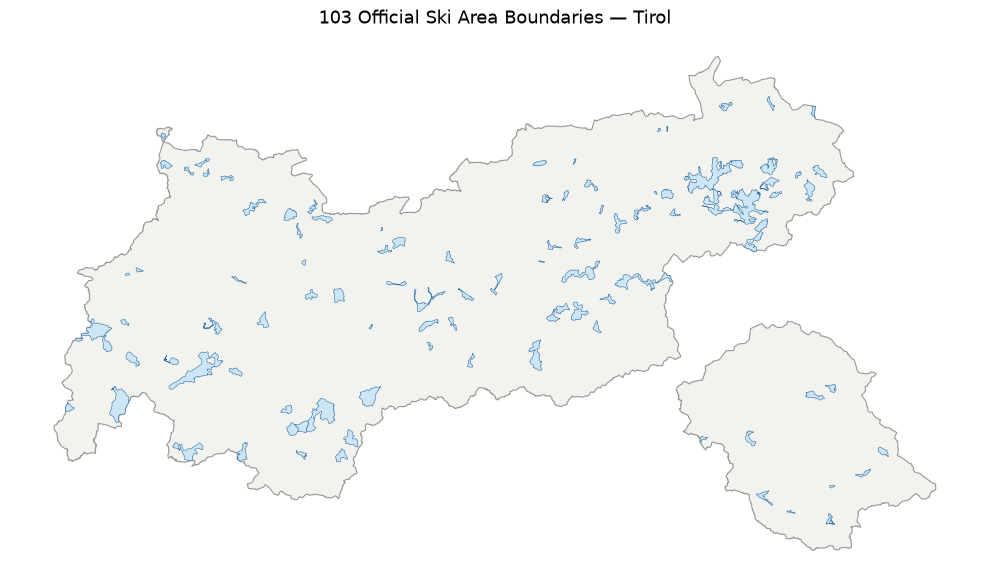

In [5]:
tirol_boundary = gpd.read_file("data_tirol_boundary.gpkg")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
tirol_boundary.plot(ax=ax, color='#f2f2ee', edgecolor='#999999', linewidth=0.8)
resorts.plot(ax=ax, color='#cde6f5', edgecolor='#2b6ca3', linewidth=0.4)
ax.set_title(f'{len(resorts)} Official Ski Area Boundaries — Tirol', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('images/resort_boundaries_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Snow-Line Exposure

For each of Tirol's 103 official ski areas, this step samples ground elevation every 50 meters along
every mapped piste, then calculates what share of each resort's total piste length lies below the
1800m snow-reliability threshold — broken down by run difficulty. It reads vector geometry (piste
lines, via GDAL through GeoPandas) and raster elevation data (via rasterio) together, then collapses
the spatial detail into a plain tabular summary per resort. Resorts with no mapped piste data inside
their official boundary are flagged and excluded from the results that follow.

In [6]:
def points_along_line(line, spacing_m=50):
    length_deg = line.length
    if length_deg == 0:
        return [line.centroid]
    n_points = max(2, int(length_deg * 111000 / spacing_m))
    return [line.interpolate(i / (n_points - 1), normalized=True) for i in range(n_points)]

def sample_elevations(dem_src, points):
    coords = [(p.x, p.y) for p in points]
    return np.array([v[0] for v in dem_src.sample(coords)])

with open("data_dem.tif", "rb") as f:
    dem_bytes = f.read()

print(f"DEM loaded: {len(dem_bytes)/1e6:.1f} MB")

DEM loaded: 9.4 MB


In [7]:
with MemoryFile(dem_bytes) as memfile, memfile.open() as dem_src:
    exposure_rows = []
    for _, row in resorts.iterrows():
        resort_poly = gpd.GeoDataFrame(geometry=[row.geometry], crs=4326)
        resort_pistes = gpd.clip(pistes, resort_poly)
        if len(resort_pistes) == 0:
            print(f"  {row['NAME']}: no data")
            continue

        per_difficulty = {}
        for line, difficulty in zip(resort_pistes.geometry, resort_pistes["difficulty"]):
            pts = points_along_line(line)
            elevations = sample_elevations(dem_src, pts)
            valid = elevations[elevations > -1000]
            if len(valid) == 0:
                continue
            seg_km = line.length * 111.0 * len(valid) / len(pts)
            below_frac = (valid < SNOW_RELIABILITY_THRESHOLD_M).mean()
            d = per_difficulty.setdefault(difficulty, {"total_km": 0.0, "below_km": 0.0})
            d["total_km"] += seg_km
            d["below_km"] += seg_km * below_frac

        total_km = sum(d["total_km"] for d in per_difficulty.values())
        below_km = sum(d["below_km"] for d in per_difficulty.values())
        above_km = total_km - below_km

        entry = {
            "resort": row["NAME"],
            "total_km": round(total_km, 1),
            "below_1800m_km": round(below_km, 1),
            "above_1800m_km": round(above_km, 1),
            "pct_below_1800m": round(100 * below_km / total_km, 1) if total_km > 0 else 0,
        }
        for diff, d in per_difficulty.items():
            entry[f"{diff}_above_km"] = round(d["total_km"] - d["below_km"], 1)
        exposure_rows.append(entry)

exposure = pd.DataFrame(exposure_rows)
print(f"\nProcessed {len(exposure)} of {len(resorts)} resorts with valid elevation data "
      f"({len(resorts) - len(exposure)} excluded -- no piste data mapped in OSM for those areas).")

  Krinnenalpe - Nesselwängle: no data
  Hochstein - Lienz: no data
  Zettersfeld - Lienz: no data
  Kleinmutzkopf - Nauders: no data
  Praxmar - St. Sigmund i.S.: no data
  Lavenar - Pettneu: no data
  Medrigjoch - See : no data
  Hochkogel - Fieberbrunn: no data
  Sorgschrofen - Jungholz: no data

Processed 94 of 103 resorts with valid elevation data (9 excluded -- no piste data mapped in OSM for those areas).


### 3a. Ranked by % below 1800m (least exposed → most exposed)

In [8]:
ranked_pct = exposure[["resort", "pct_below_1800m", "total_km"]].sort_values(
    "pct_below_1800m", ascending=True
).reset_index(drop=True)
ranked_pct.index += 1

print(f"Top 10 of {len(ranked_pct)} resorts, LEAST to MOST exposed (% below 1800m)")
print(f"(full ranking saved to 03a_pct_below_1800m.csv):\n")
ranked_pct.to_csv("03a_pct_below_1800m.csv")
ranked_pct.head(10)

Top 10 of 94 resorts, LEAST to MOST exposed (% below 1800m)
(full ranking saved to 03a_pct_below_1800m.csv):



,resort,pct_below_1800m,total_km
1,Stablein - Vent,0.0,11.9
2,Pitztaler Gletscher,0.0,75.2
3,Kaunertaler Gletscher,0.0,35.6
4,Kühtai,0.0,39.4
5,Albonagrat - St. Anton,0.0,6.4
6,Obergurgl,0.0,42.2
7,Lämmerbichl-Rastkogel - Tux,0.0,28.1
8,Staller Sattel - St. Jakob in Defereggen,0.0,5.5
9,Erweiterung Gletscherschigebiet - Verbindung Ö...,0.0,1.9
10,Hochgurgl,0.4,42.0


### 3b. Ranked by km below 1800m (least → most)

In [9]:
ranked_km = exposure[["resort", "below_1800m_km", "total_km"]].sort_values(
    "below_1800m_km", ascending=True
).reset_index(drop=True)
ranked_km.index += 1

print(f"Top 10 of {len(ranked_km)} resorts, LEAST to MOST km below 1800m")
print(f"(full ranking saved to 03b_km_below_1800m.csv):\n")
ranked_km.to_csv("03b_km_below_1800m.csv")
ranked_km.head(10)

Top 10 of 94 resorts, LEAST to MOST km below 1800m
(full ranking saved to 03b_km_below_1800m.csv):



,resort,below_1800m_km,total_km
1,Stablein - Vent,0.0,11.9
2,Pitztaler Gletscher,0.0,75.2
3,Kaunertaler Gletscher,0.0,35.6
4,Kühtai,0.0,39.4
5,Albonagrat - St. Anton,0.0,6.4
6,Obergurgl,0.0,42.2
7,Lämmerbichl-Rastkogel - Tux,0.0,28.1
8,Staller Sattel - St. Jakob in Defereggen,0.0,5.5
9,Erweiterung Gletscherschigebiet - Verbindung Ö...,0.0,1.9
10,Hochgurgl,0.2,42.0


### 3c. Terrain ABOVE 1800m by difficulty (most → least km above threshold)

The "safe" terrain, broken down by run difficulty — useful for seeing which resorts have
genuinely diverse safe terrain versus just a handful of easy runs at altitude.

In [10]:
above_cols = [c for c in exposure.columns if c.endswith("_above_km") and c != "above_1800m_km"]
difficulty_above = exposure[["resort", "above_1800m_km"] + above_cols].sort_values(
    "above_1800m_km", ascending=False
).reset_index(drop=True)
difficulty_above.index += 1

print(f"Top 10 of {len(difficulty_above)} resorts, MOST to LEAST km above 1800m by difficulty")
print(f"(full ranking saved to 03c_difficulty_above_1800m.csv):\n")
difficulty_above.to_csv("03c_difficulty_above_1800m.csv")
difficulty_above.head(10)

Top 10 of 94 resorts, MOST to LEAST km above 1800m by difficulty
(full ranking saved to 03c_difficulty_above_1800m.csv):



,resort,above_1800m_km,easy_above_km,expert_above_km,novice_above_km,intermediate_above_km,advanced_above_km,freeride_above_km,unknown_above_km,extreme_above_km
1,Komperdell,324.0,67.2,NaN,0.0,201.6,34.1,21.1,NaN,NaN
2,Silvretta Schiarena,315.3,68.1,0.8,5.2,152.7,74.8,13.8,NaN,NaN
3,Ötztaler Gletscher,205.7,100.0,NaN,0.3,69.8,35.6,NaN,0.0,NaN
4,Hintertuxer Gletscher,154.2,61.8,NaN,NaN,88.1,4.3,NaN,NaN,NaN
5,Hochzillertal - Kaltenbach - Aschau,149.9,41.0,NaN,NaN,76.7,27.0,5.2,NaN,NaN
6,Schi Zell - Kreuzjochbahn,132.4,25.9,NaN,0.9,94.3,10.8,0.5,NaN,NaN
7,Bergkastel - Tscheyeck - Nauders,99.9,16.3,0.9,0.6,60.1,15.9,6.2,NaN,NaN
8,Stubaier Gletscher,80.1,33.5,NaN,1.9,37.2,5.7,1.9,NaN,NaN
9,Pitztaler Gletscher,75.2,28.9,NaN,0.8,42.2,2.1,1.2,NaN,NaN
10,Diasalpe - Kappl,72.4,20.3,NaN,NaN,35.9,16.0,NaN,0.3,NaN


## 4. On-Mountain Venue Counts

Restaurants and bars within 100m of an actual piste — not a flat count within the whole
resort boundary, which would mostly measure the base village rather than the mountain itself.

In [11]:
venues = gpd.read_file("data_venues.gpkg")
print(f"Venues loaded: {venues.shape}")

venue_rows = []
for _, row in resorts.iterrows():
    resort_poly = gpd.GeoDataFrame(geometry=[row.geometry], crs=4326)
    resort_pistes = gpd.clip(pistes, resort_poly)
    if len(resort_pistes) == 0 or len(venues) == 0:
        venue_rows.append({"resort": row["NAME"], "on_mountain_venue_count": 0})
        continue
    pistes_m = resort_pistes.to_crs(AUSTRIA_CRS)
    venues_m = venues.to_crs(AUSTRIA_CRS)
    piste_buffer = pistes_m.geometry.buffer(ON_MOUNTAIN_DISTANCE_M).union_all()
    count = int(venues_m.geometry.within(piste_buffer).sum())
    venue_rows.append({"resort": row["NAME"], "on_mountain_venue_count": count})

venue_counts = pd.DataFrame(venue_rows).sort_values(
    "on_mountain_venue_count", ascending=False
).reset_index(drop=True)
venue_counts.index += 1

print(f"Top 10 of {len(venue_counts)} resorts, MOST to LEAST on-mountain venues")
print(f"(full ranking saved to 04_venue_counts.csv):\n")
venue_counts.to_csv("04_venue_counts.csv")
venue_counts.head(10)

Venues loaded: (7464, 5)
Top 10 of 103 resorts, MOST to LEAST on-mountain venues
(full ranking saved to 04_venue_counts.csv):



,resort,on_mountain_venue_count
1,Schiwelt Wilder Kaiser - Brixental,62
2,Ötztaler Gletscher,61
3,Hahnenkamm - Ehrenbachhöhe,41
4,Komperdell,40
5,Silvretta Schiarena,35
6,Albonagrat - St. Anton,28
7,Schi Zell - Kreuzjochbahn,24
8,Hochzillertal - Kaltenbach - Aschau,21
9,Penken,21
10,"Choralm - Westendorf, Kandleralm - Brixen",19


## 5. Venue Density (venues per km²)

Same normalization principle as the hydrant density project: raw counts favor bigger resorts.
Dividing by area makes different-sized resorts fairly comparable — but for very small polygons,
this ratio becomes unstable. One resort in the official dataset has an area of ~0.00002 km²
(a data artifact, not a real ski area footprint), which produced a nonsensical density in the
tens of thousands per km². Resorts under 1 km² are excluded from this ranking for that reason.

In [12]:
resorts_m = resorts.to_crs(AUSTRIA_CRS)
resorts["area_km2"] = resorts_m.geometry.area / 1e6

density = resorts[["NAME", "area_km2"]].rename(columns={"NAME": "resort"}).merge(
    venue_counts, on="resort", how="left"
)
density["venue_density_per_km2"] = (
    density["on_mountain_venue_count"] / density["area_km2"]
).round(2)

density_filtered = density[density["area_km2"] >= MIN_AREA_KM2]
excluded_count = len(density) - len(density_filtered)

density_ranked = density_filtered.sort_values("venue_density_per_km2", ascending=False).reset_index(drop=True)
density_ranked.index += 1

print(f"Top 10 of {len(density_ranked)} resorts ≥{MIN_AREA_KM2} km², MOST to LEAST venue density per km²")
print(f"({excluded_count} smaller resorts excluded -- density is unstable on tiny areas)")
print(f"(full ranking saved to 05_venue_density.csv):\n")
density_ranked.to_csv("05_venue_density.csv")
density_ranked.head(10)

Top 10 of 88 resorts ≥1 km², MOST to LEAST venue density per km²
(19 smaller resorts excluded -- density is unstable on tiny areas)
(full ranking saved to 05_venue_density.csv):



,resort,area_km2,on_mountain_venue_count,venue_density_per_km2
1,Neunerköpfle - Tannheim,1.420866,5,3.52
2,Spieljoch,2.768025,9,3.25
3,Birkhahn - Galtür,2.519007,8,3.18
4,Hochimst,1.123028,3,2.67
5,Marienbergjoch,1.614441,4,2.48
6,Mutterer Alm,1.213198,3,2.47
7,Ötztaler Gletscher,25.564210,61,2.39
8,Penken,8.787354,21,2.39
9,Obergurgl,4.636212,11,2.37
10,Gschwandtkopf,2.178608,5,2.30


## 6. Visual Density Map

Same 1 km² minimum-area filter as Chapter 5, applied for the same reason. The color scale is also
fixed to defined steps (0–3, in increments of 0.5) rather than scaling automatically to the data's
min/max — this keeps the map readable and stable regardless of any single outlier value.

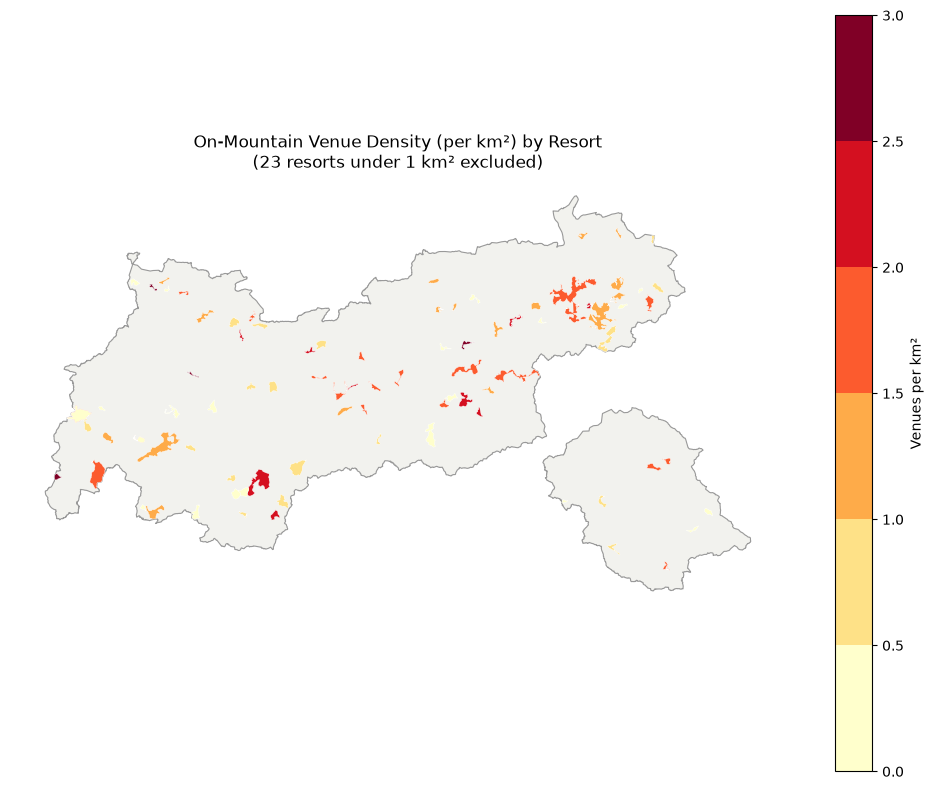

In [13]:
resorts_with_density = resorts.merge(
    density[["resort", "venue_density_per_km2"]], left_on="NAME", right_on="resort", how="left"
)
resorts_for_density = resorts_with_density[resorts_with_density["area_km2"] >= MIN_AREA_KM2]
excluded = len(resorts_with_density) - len(resorts_for_density)

bounds = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
cmap = plt.cm.YlOrRd
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
tirol_boundary.plot(ax=ax, color='#f2f2ee', edgecolor='#999999', linewidth=0.8)
resorts_for_density.plot(
    ax=ax, column='venue_density_per_km2', cmap=cmap, norm=norm, legend=True,
    edgecolor='white', linewidth=0.3,
    legend_kwds={'ticks': bounds, 'label': 'Venues per km²'},
    missing_kwds={"color": "#eeeeee"},
)
ax.set_title(f'On-Mountain Venue Density (per km²) by Resort\n'
             f'({excluded} resorts under {MIN_AREA_KM2} km² excluded)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('images/venue_density_choropleth.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Export to GeoParquet

In [14]:
final = resorts_with_density.merge(exposure, left_on="NAME", right_on="resort", how="left")
final = final.drop(columns=[c for c in ["resort_x", "resort_y", "resort"] if c in final.columns])

output_path = "tirol_snowline_results.parquet"
final.to_parquet(output_path)

result = gpd.read_parquet(output_path)
print(f"Exported to: {output_path}")
print(f"Shape: {result.shape}")
print(f"Columns: {list(result.columns)}")

Exported to: tirol_snowline_results.parquet
Shape: (123, 26)
Columns: ['OBJECTID', 'OBJEKT', 'OBJEKTBEZEICHNUNG', 'NAME', 'SCHIG_NR', 'ERFASSUNGSMASSSTAB', 'STAND', 'CREATETIMESTAMP', 'UPDATETIMESTAMP', 'Shape__Area', 'Shape__Length', 'geometry', 'area_km2', 'venue_density_per_km2', 'total_km', 'below_1800m_km', 'above_1800m_km', 'pct_below_1800m', 'easy_above_km', 'expert_above_km', 'novice_above_km', 'intermediate_above_km', 'advanced_above_km', 'freeride_above_km', 'unknown_above_km', 'extreme_above_km']


## Summary

In this notebook you:
1. Loaded official Tirol ski area boundaries and OSM piste data, ranked all 103 by piste km
2. Mapped all resort boundaries with the Tirol province outline as geographic context
3. Sampled elevation along every piste (via GDAL/GeoPandas + rasterio) to compute snow-line
   exposure — by %, by km, and by safe terrain per difficulty level; 94 of 103 resorts had
   usable piste data, 9 were excluded for having none mapped in OSM
4. Counted on-mountain venues within 100m of pistes (Overture Places via DuckDB/S3)
5. Computed area-normalized venue density, excluding resorts under 1 km² (unstable ratio
   on near-zero-area polygons)
6. Visualized density as a choropleth with a fixed, stepped color scale
7. Exported the combined result to GeoParquet

## What I learned

The biggest lesson was architectural: my first version made a fresh Overpass/DEM/Overture
query for every single resort, which meant 100+ network round-trips and painfully slow runs.
Rewriting it to fetch each data source once for the whole province, then clip and sample
locally per resort, cut the runtime from over 30 minutes to under 90 seconds — the same
"push work to the source, not to Python" lesson from the hydrant project's DuckDB
aggregation, just applied at pipeline scale. I also learned to distrust convenient
shortcuts: a radius around each resort's center point badly over- or under-shot real piste
extent in Tirol's densely interconnected terrain, and only switching to the official
government boundary polygons fixed it properly. Finally, a density calculation is only as
good as its denominator — one resort with a near-zero official area produced a nonsensical
density value that would have skewed the whole map if I hadn't filtered it out and
documented why.